In [2]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [3]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [4]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [6]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [7]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
nthreads = 18

In [10]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [11]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [12]:
mask_type = 'selfunc'

# Visuals

In [13]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [14]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [15]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [16]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [17]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

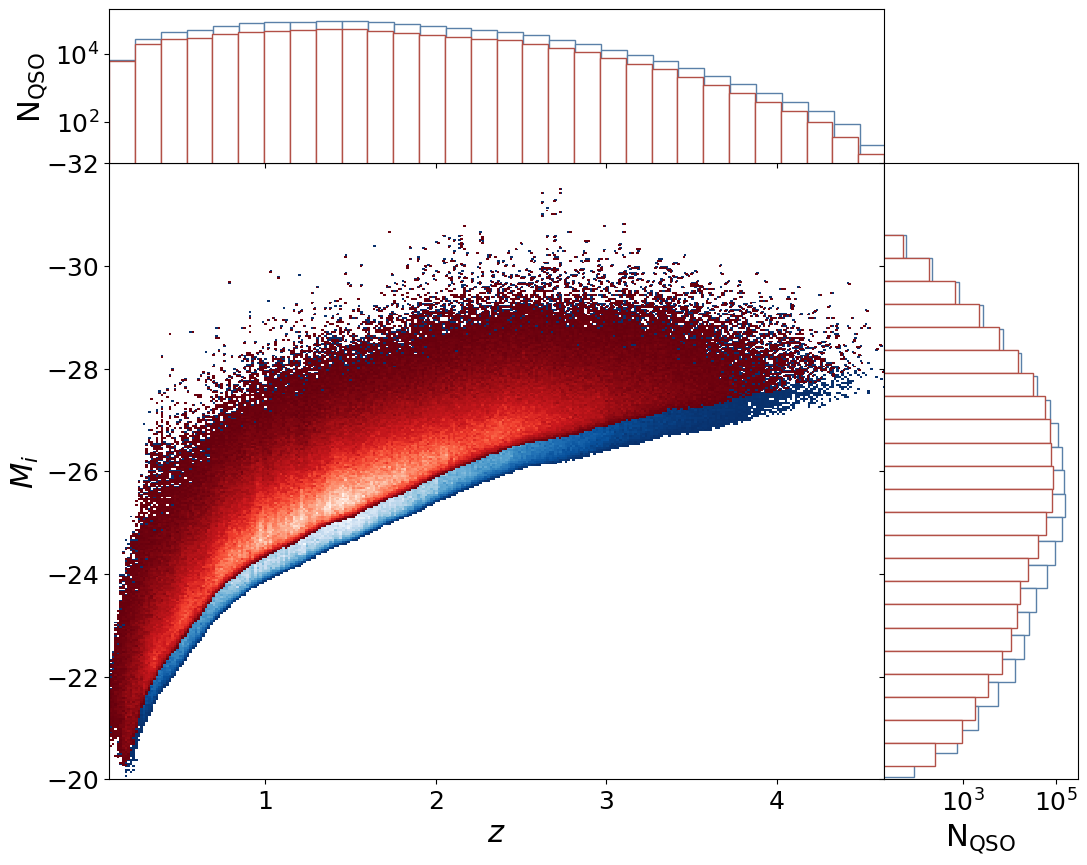

In [18]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in three L bins
## $\xi(s)$

In [19]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [20]:
L_array = [0,1,2,3]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [G_lo, G_hi]
labels = ['$-32<M_i\leq-30$', '$-30<M_i\leq-28$', '$-28<M_i\leq-24$', '$-24<M_i\leq-20$']
L_bins = [-32.0, -30.0, -28.0, -24.0, -20.0]

_G20.0_Lmin-32.0Lmax-30.0


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


$-32<M_i\leq-30$ -31.661861549418575 -30.00041364349355 

_G20.0_Lmin-30.0Lmax-28.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


$-30<M_i\leq-28$ -29.999386731843344 -28.000012144781685 

_G20.0_Lmin-28.0Lmax-24.0


...

$-30<M_i\leq-28$ -29.999812425577804 -28.000041948005993 

_G20.5_Lmin-28.0Lmax-24.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


$-28<M_i\leq-24$ -27.99993979849718 -24.00000743910973 

_G20.5_Lmin-24.0Lmax-20.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


$-24<M_i\leq-20$ -23.999977576816452 -20.05062846457238 



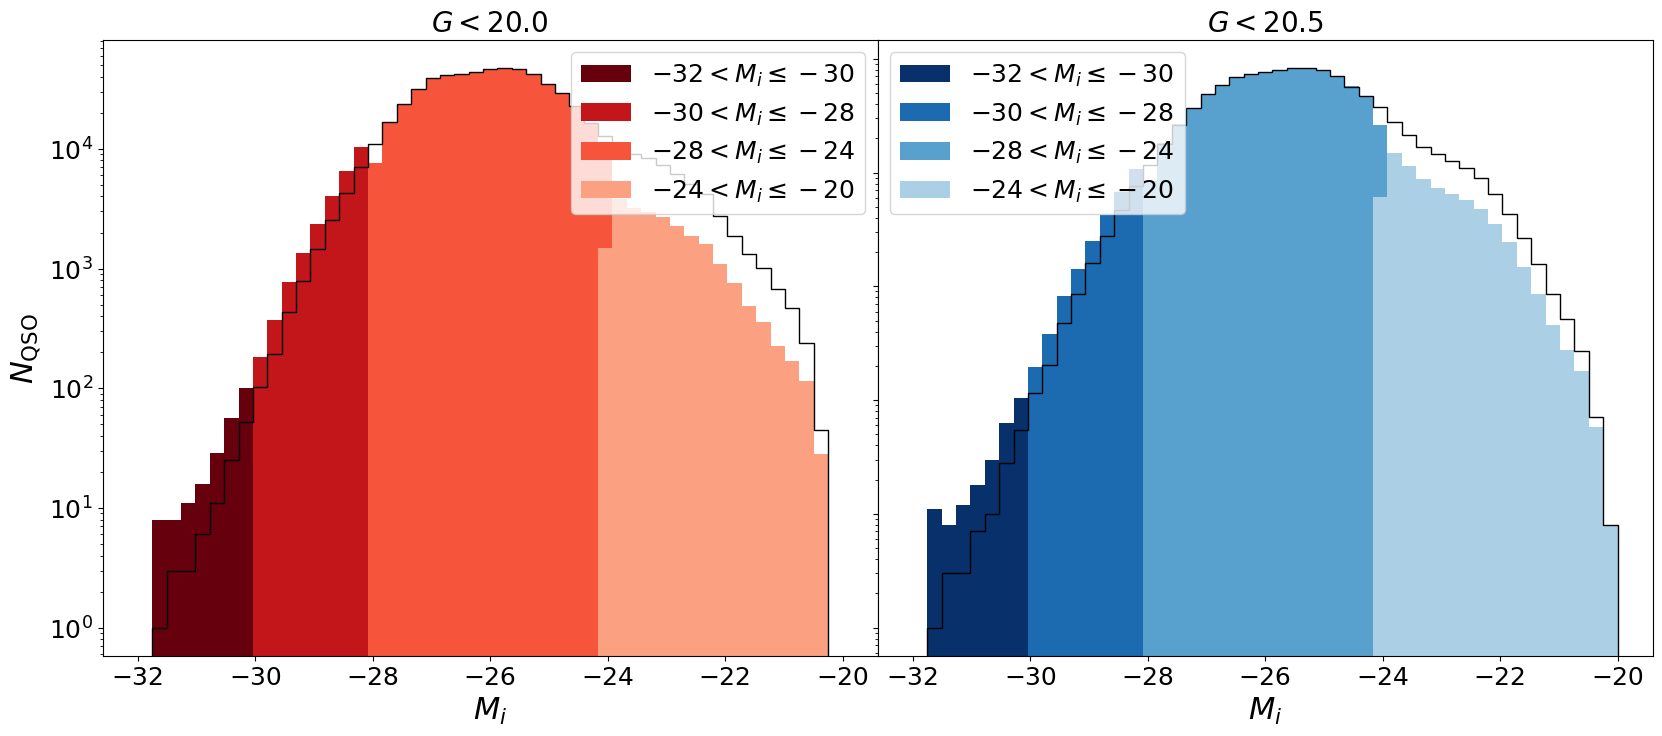

In [21]:
# plot data
bins = np.linspace(-32,-20)
cf = {20.0: [], 20.5: []}

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    ax1 = fig.add_subplot(gs[i])
    ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')

    for Lbin, label in zip(L_array, labels):
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G_array[i], Lbin, True, 'L', bins = L_bins,
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)
        ax1.hist(tab_datahi_mask_zbin0['M_i'], label = label, bins = bins, color = cmaps[i][Lbin])
        
        cf[G_array[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))
        print(label, np.min(tab_datahi_mask_zbin0['M_i']), np.max(tab_datahi_mask_zbin0['M_i']), '\n')

    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel('$M_i$')
    ax1.set_yscale('log')
    ax1.legend()
    if i>0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

In [22]:
# for Lbin in L_array:
#     test = Table.read('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/data/quaia_G20.5_Lsplit3bin{}.fits'.format(i))
#     print(len(test))
#     print(N_datahi_mask_zbin0/len(test))

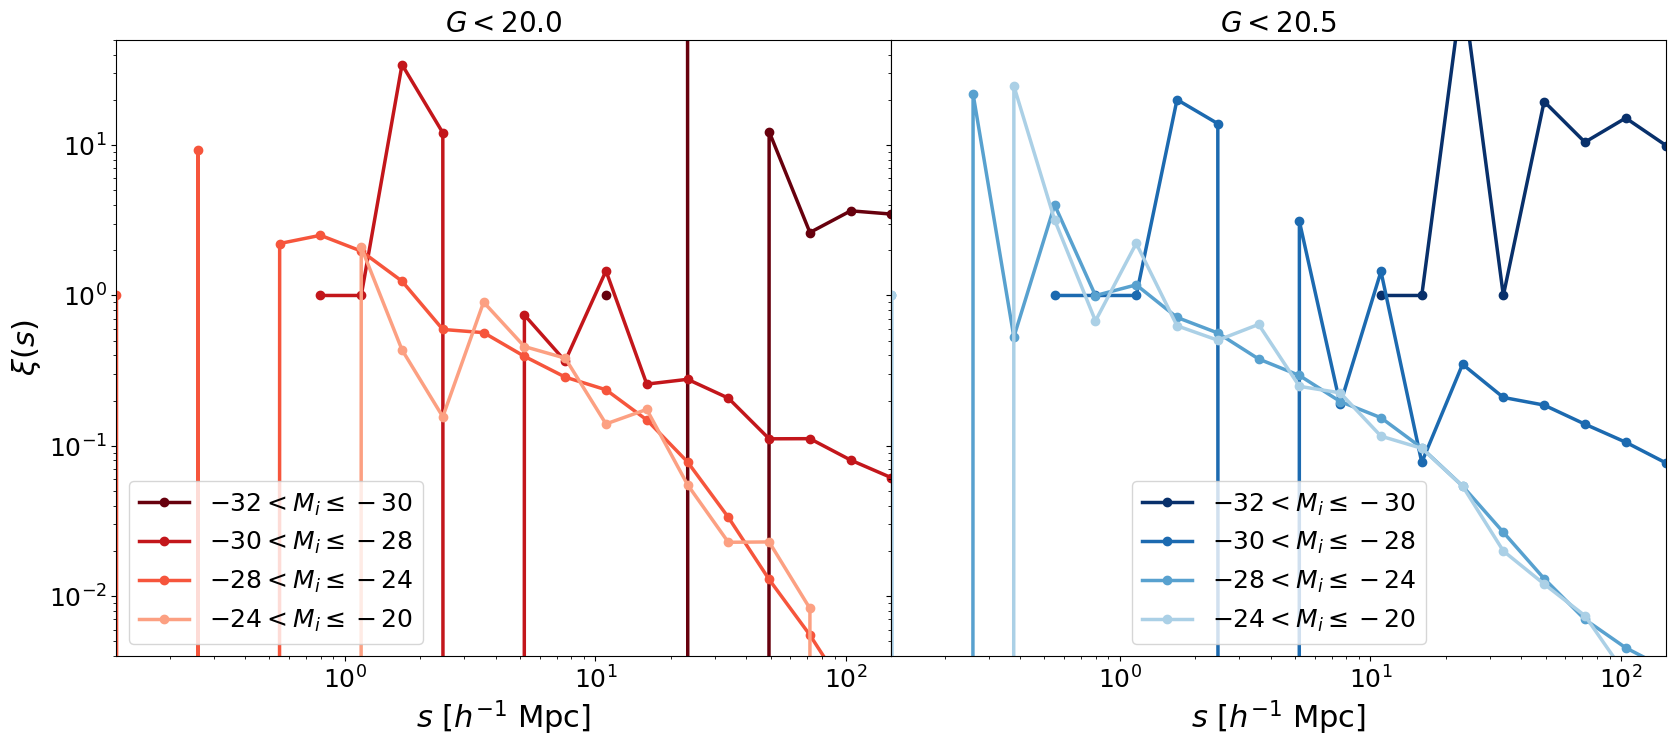

In [23]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for Lbin, label in zip(L_array, labels):
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

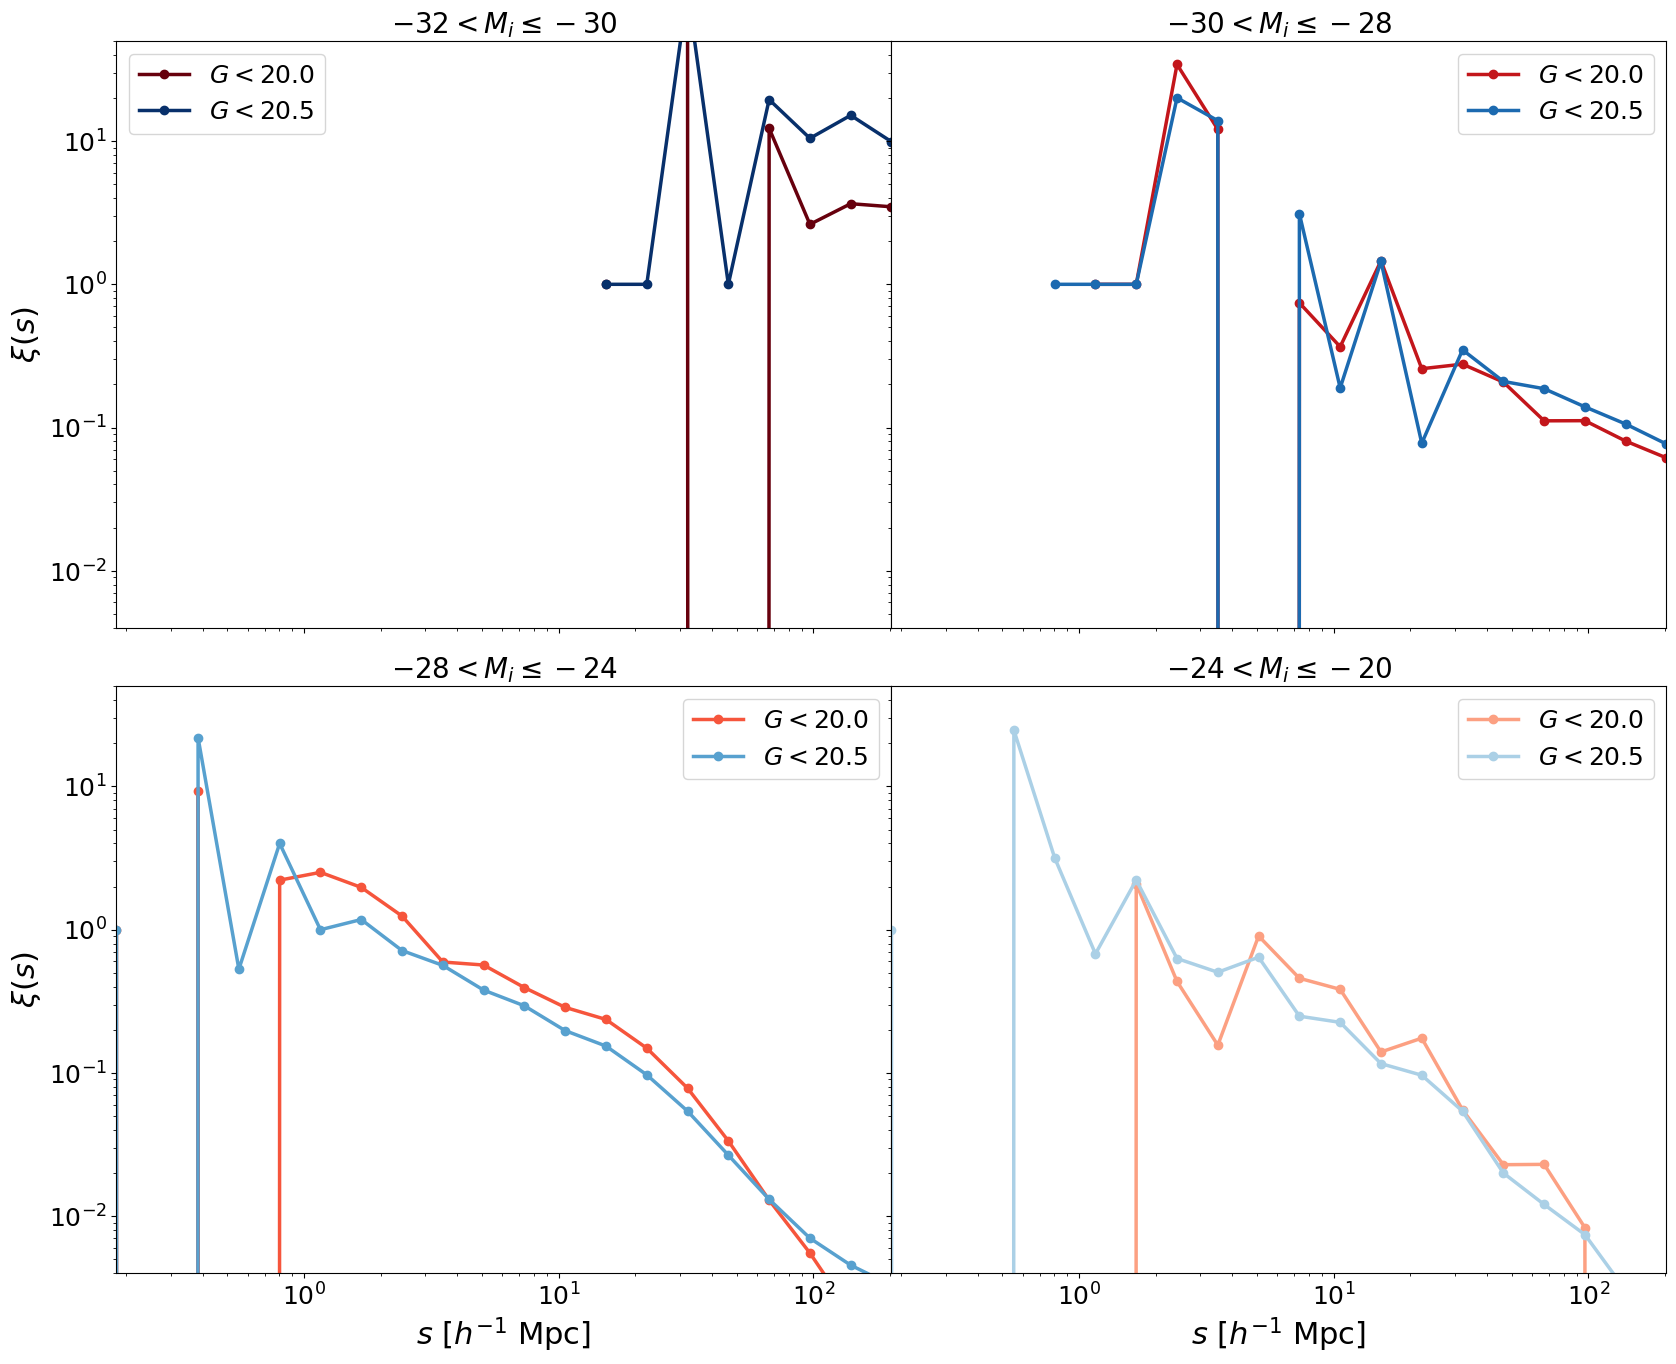

In [31]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title, i in zip(L_array, labels, L_array):
    
    ax1 = fig.add_subplot(gs[i])
    
    for G, cmap in zip(G_array, cmaps):
        
        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(4e-3, 5e1)
    ax1.legend()
    if i%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    if i>1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

## $w_p(r_p)$

In [25]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [26]:
pimax = 80 # 40 # 5000.0 # 40.0

In [27]:
# plot data
# bins = np.linspace(0.08, 4.6)
wp, rpavg = {G_lo: [], G_hi: []}, {G_lo: [], G_hi: []}
for G in G_array:

    for Lbin in L_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, Lbin, True, 'L', z = True, bins = L_bins, 
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins,
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-30.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:653: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


_G20.0_Lmin-30.0Lmax-28.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:653: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


_G20.0_Lmin-28.0Lmax-24.0


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:653: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


_G20.5_Lmin-28.0Lmax-24.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-24.0Lmax-20.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


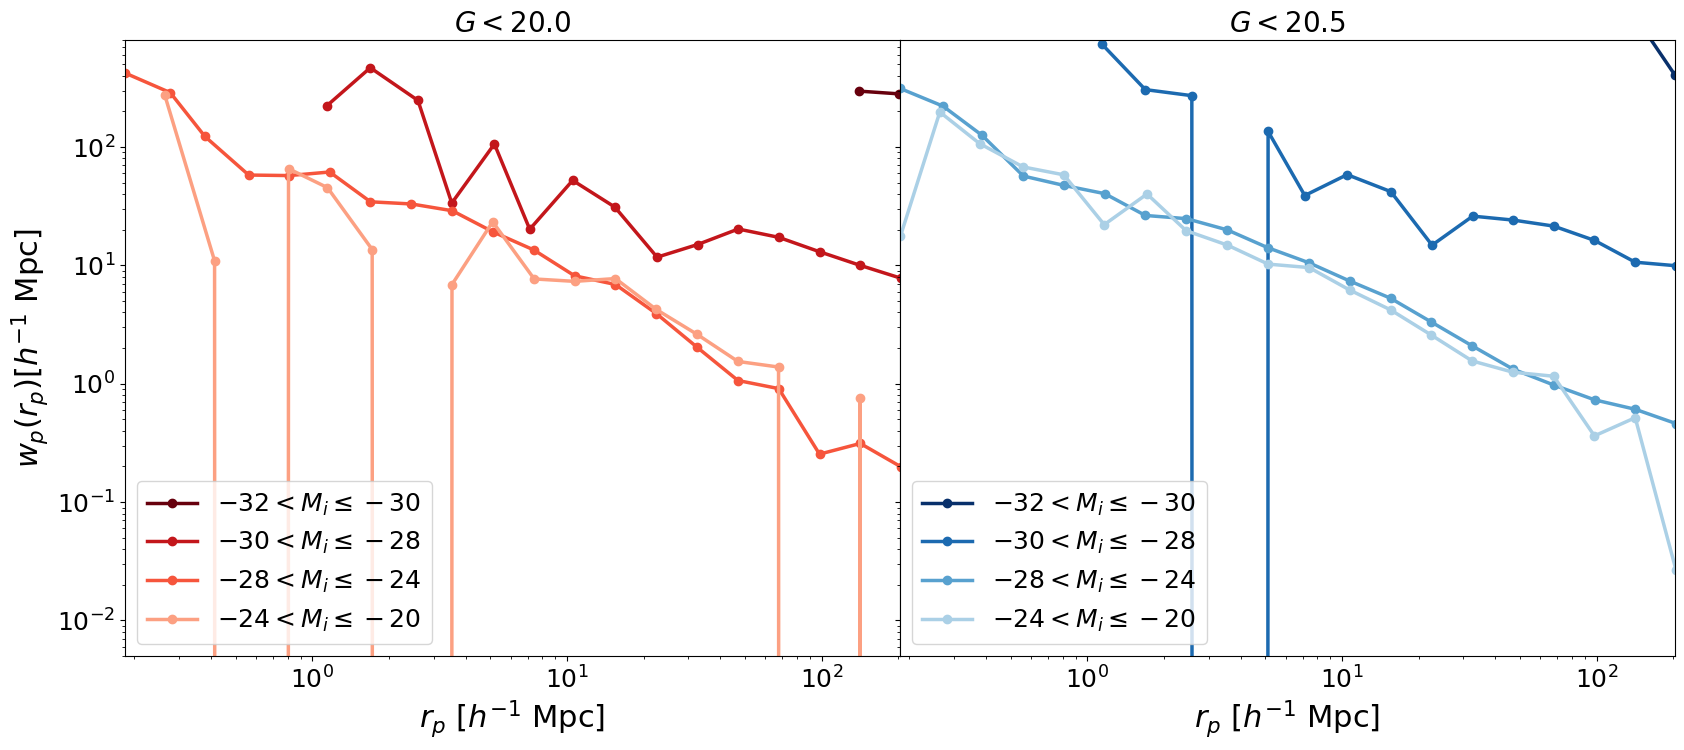

In [28]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(5e-3, 8e2)
    ax1.legend()
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

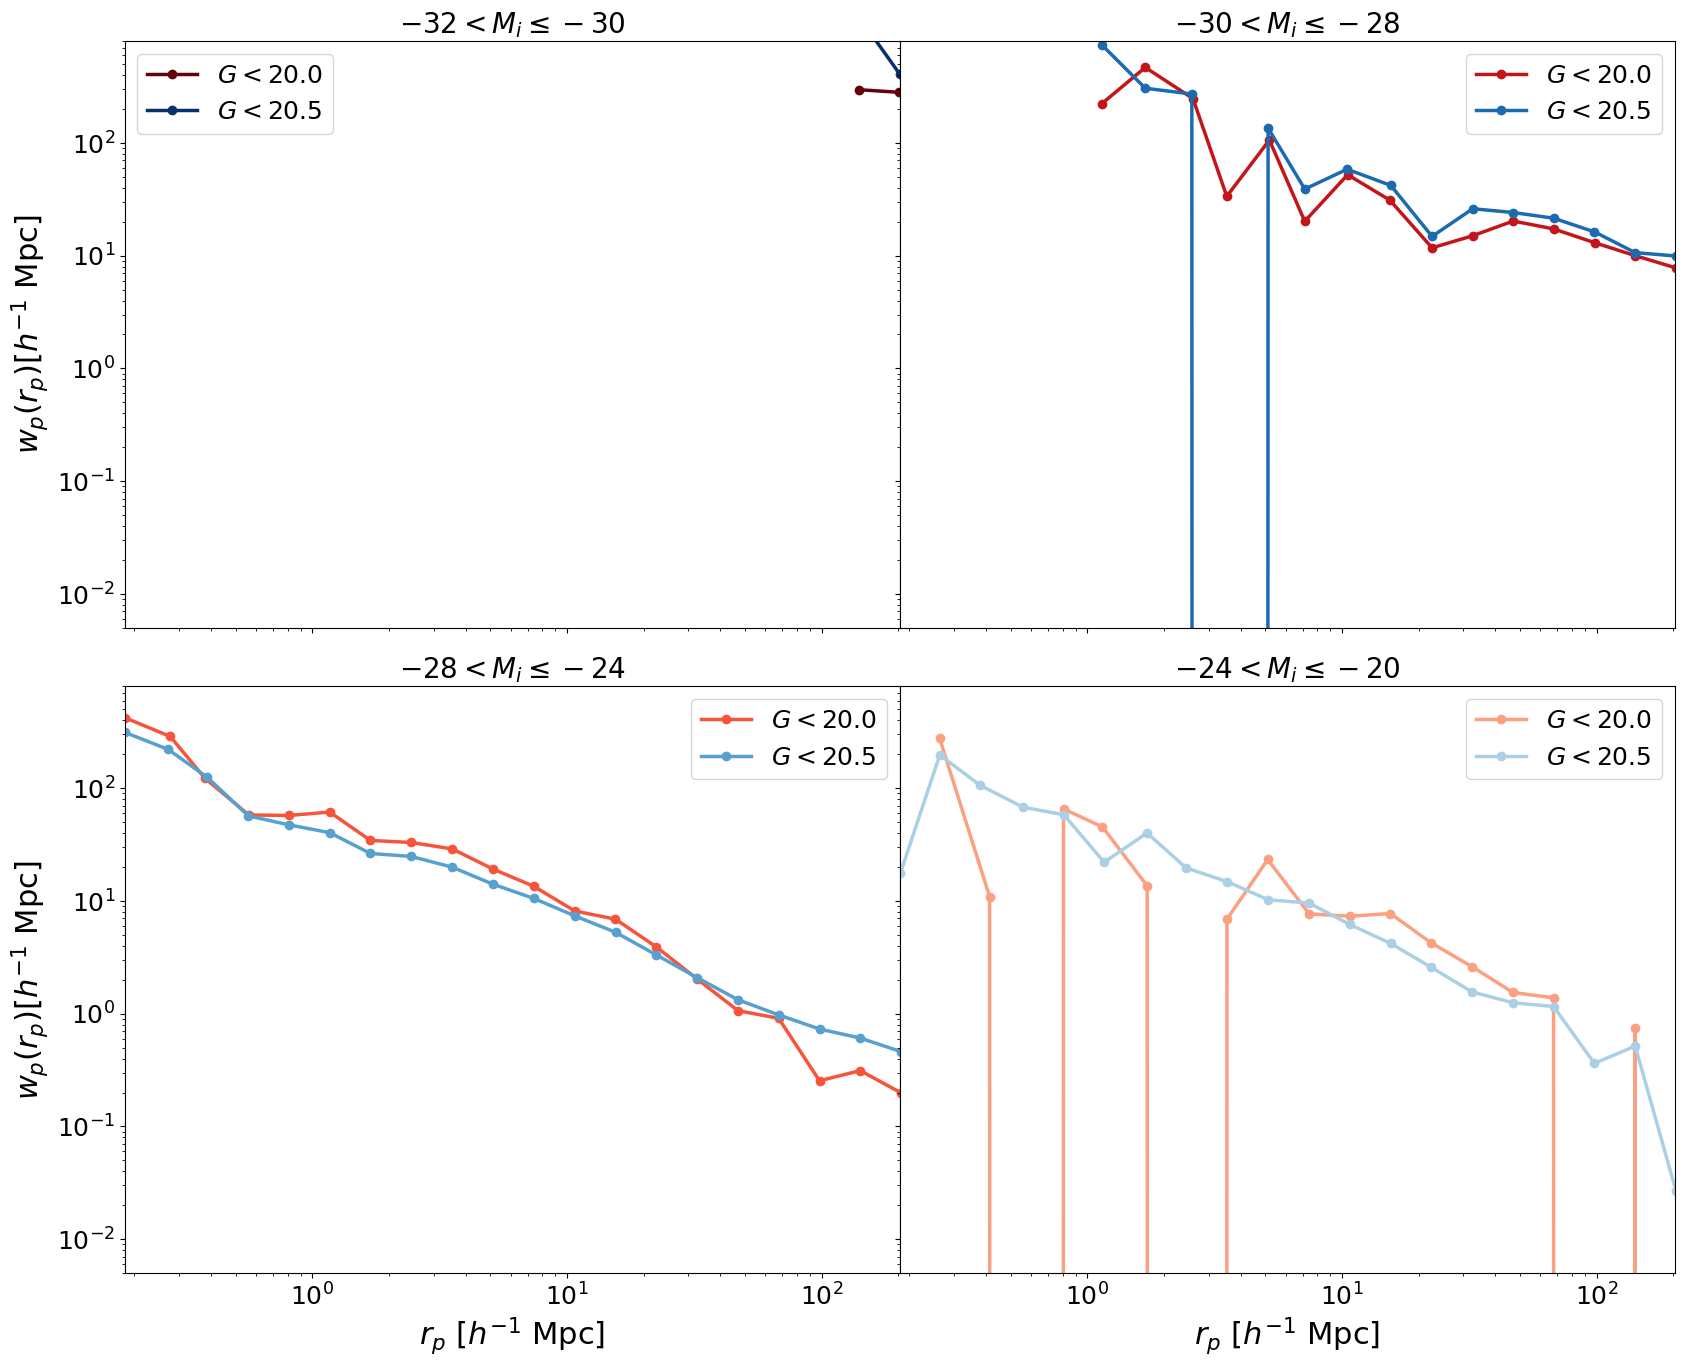

In [33]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title, i in zip(L_array, labels, L_array):
    
    ax1 = fig.add_subplot(gs[i])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(5e-3, 8e2)
    ax1.legend()
    if i%2==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])
    if i>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

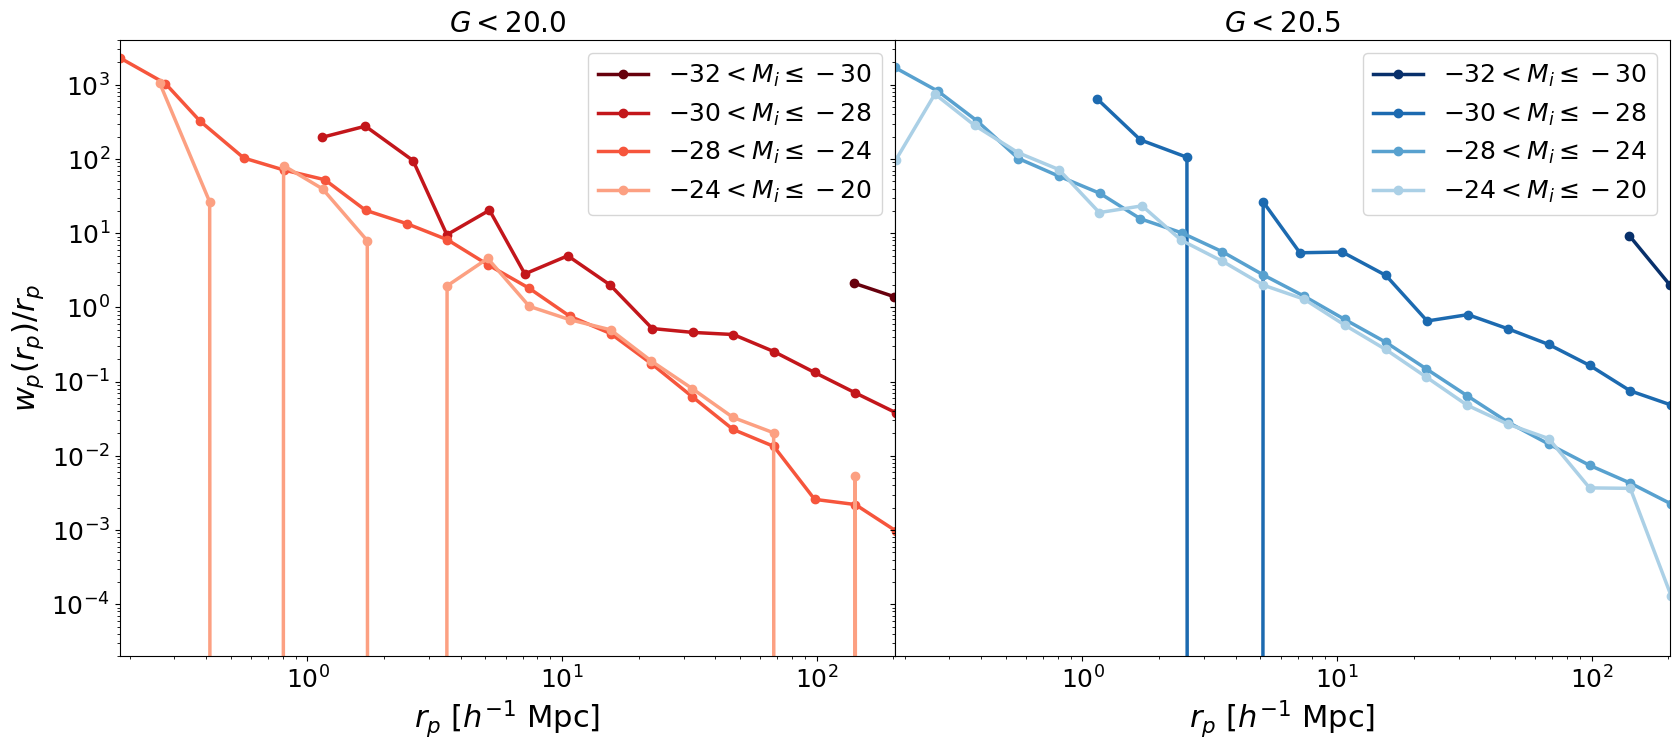

In [34]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-5, 4e3)
    ax1.legend()
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

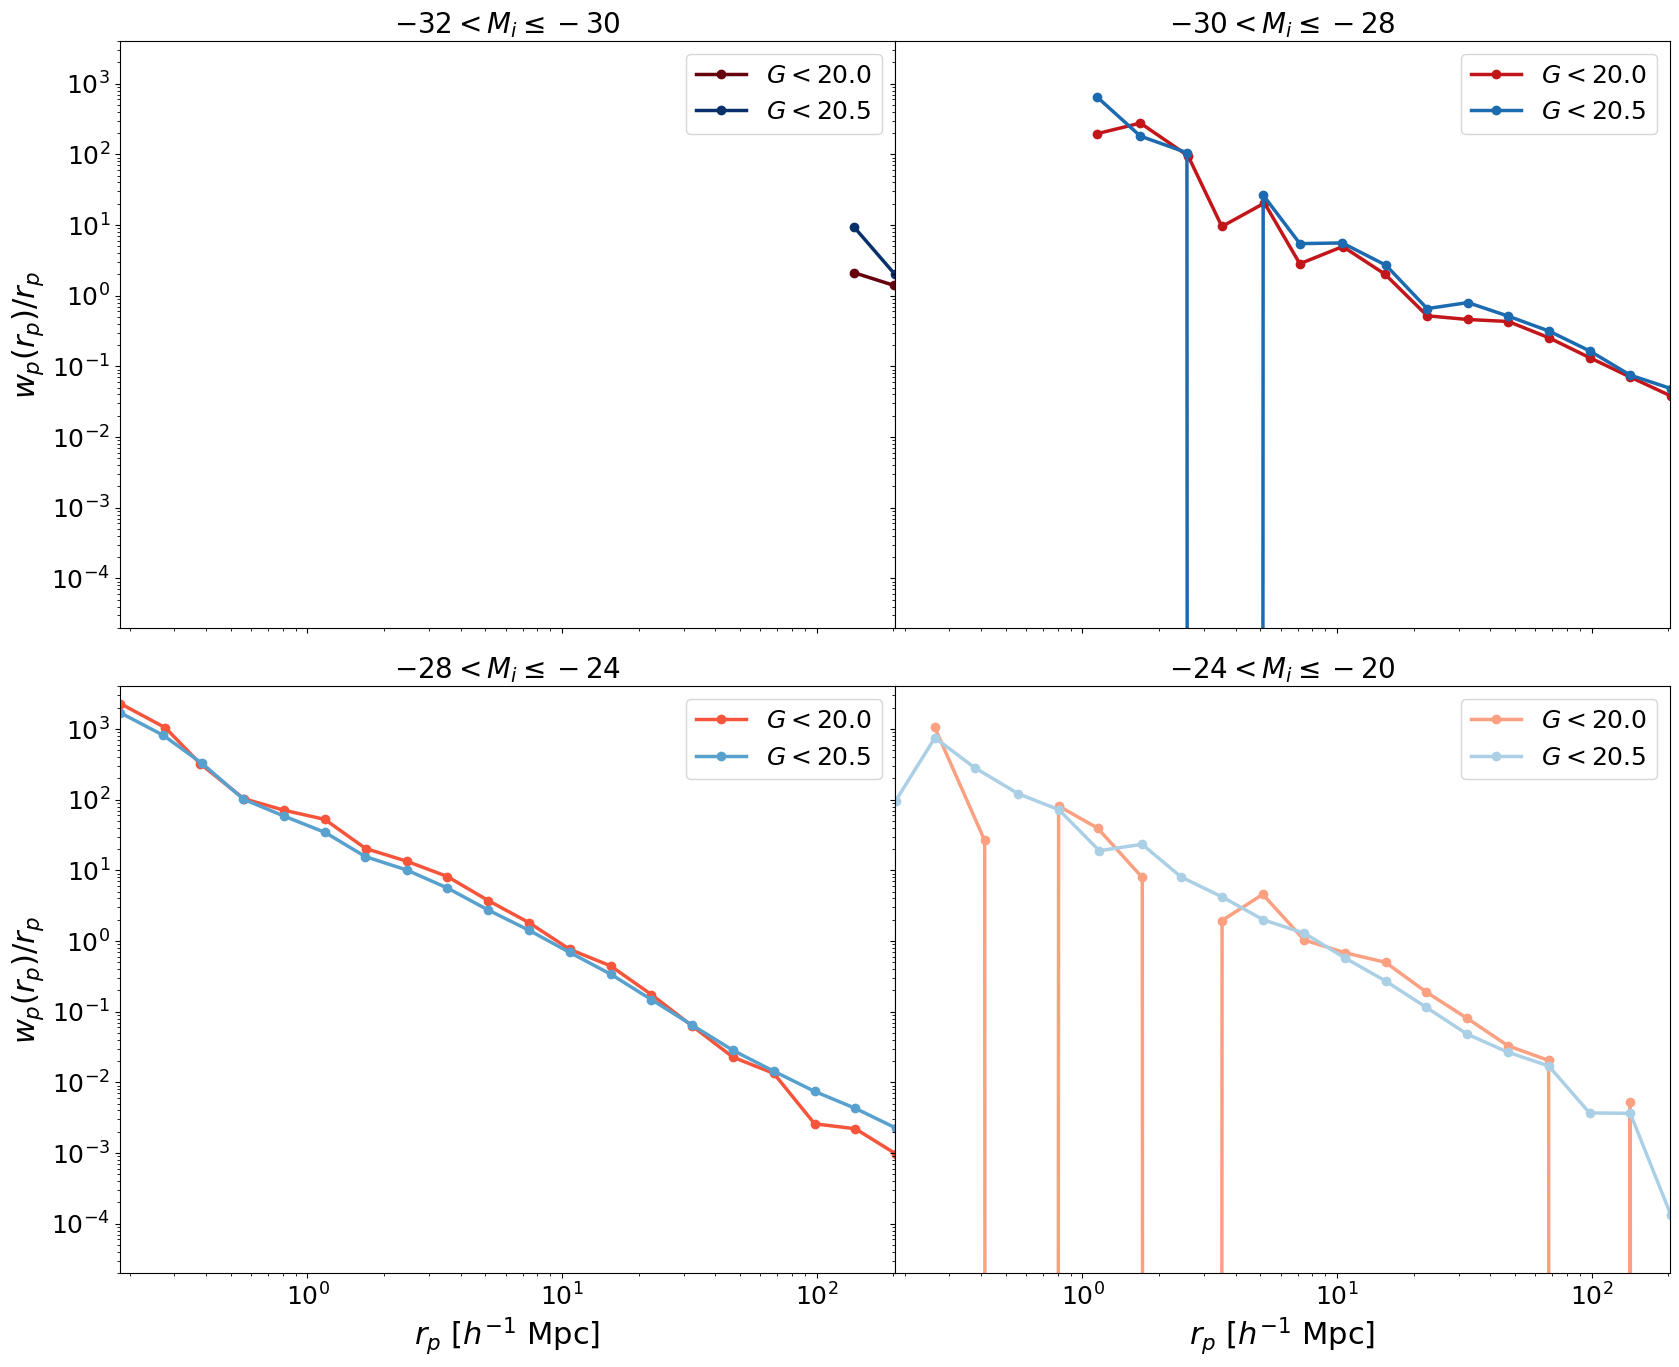

In [35]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title, i in zip(L_array, labels, L_array):
    
    ax1 = fig.add_subplot(gs[i])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-5, 4e3)
    ax1.legend()
    if i%2==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if i>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

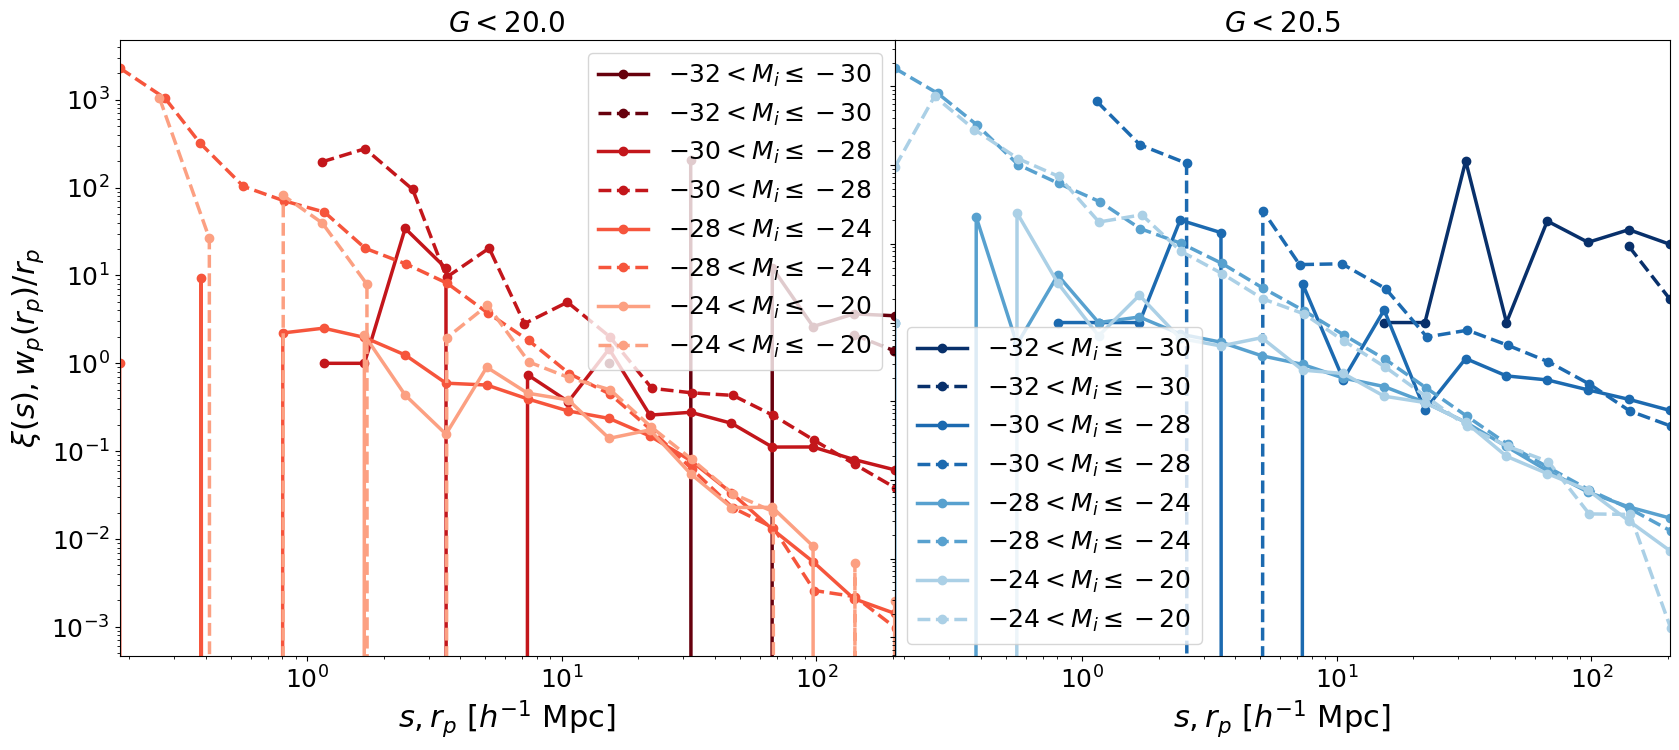

In [39]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin], linestyle = '--')
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    # ax1.set_ylim(5e-3, 8e2)
    ax1.legend()
    if i==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

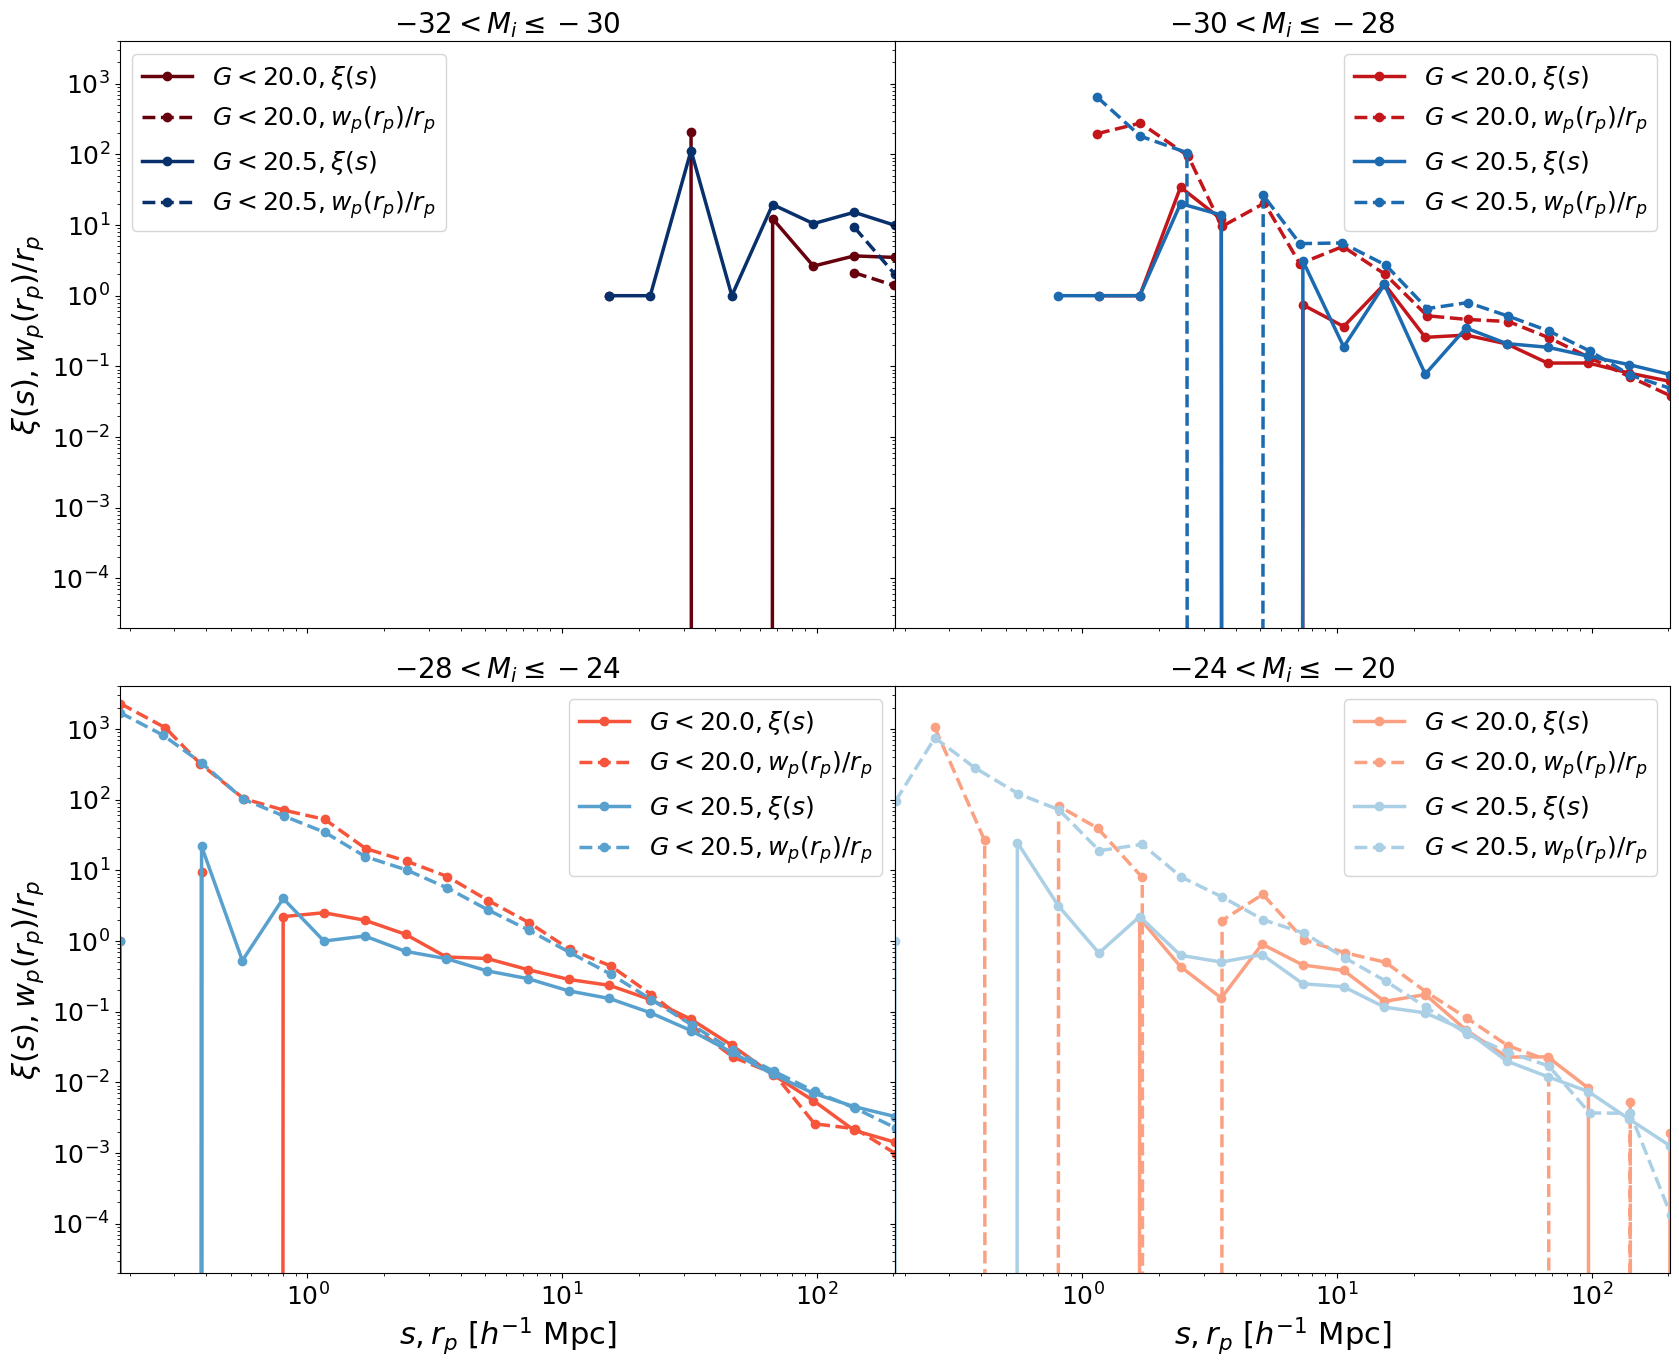

In [41]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title, i in zip(L_array, labels, L_array):
    
    ax1 = fig.add_subplot(gs[i])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}, \\xi(s)$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}, w_p(r_p)/r_p$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin], linestyle = '--')
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-5, 4e3)
    ax1.legend()
    if i%2==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if i>1:
        ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

## $w(\theta)$

In [42]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [44]:
# plot data
wtheta = {G_lo: [], G_hi: []}
for G in G_array:

    for Lbin in L_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, _, _, _ = quaia.make_bins(G, Lbin, True, 'L', z = False, bins = L_bins, 
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-30.0
DD: 0.0009519999999999999
DR: 0.0040539999999999994
RR: 0.0053809999999999995
_G20.0_Lmin-30.0Lmax-28.0
DD: 0.041707
DR: 1.087451
RR: 10.879289
_G20.0_Lmin-28.0Lmax-24.0
DD: 10.560605
DR: 524.311836
RR: 5218.98128
_G20.0_Lmin-24.0Lmax-20.0
DD: 0.061765
DR: 2.933274
RR: 29.503637
_G20.5_Lmin-32.0Lmax-30.0
DD: 0.0015739999999999999
DR: 0.004605
RR: 0.0045969999999999995
_G20.5_Lmin-30.0Lmax-28.0
DD: 0.056701999999999995
DR: 2.018689
RR: 22.457105
_G20.5_Lmin-28.0Lmax-24.0
DD: 19.955326
DR: 1610.415266
RR: 21099.12668
_G20.5_Lmin-24.0Lmax-20.0
DD: 0.309758
DR: 9.924308
RR: 112.325579


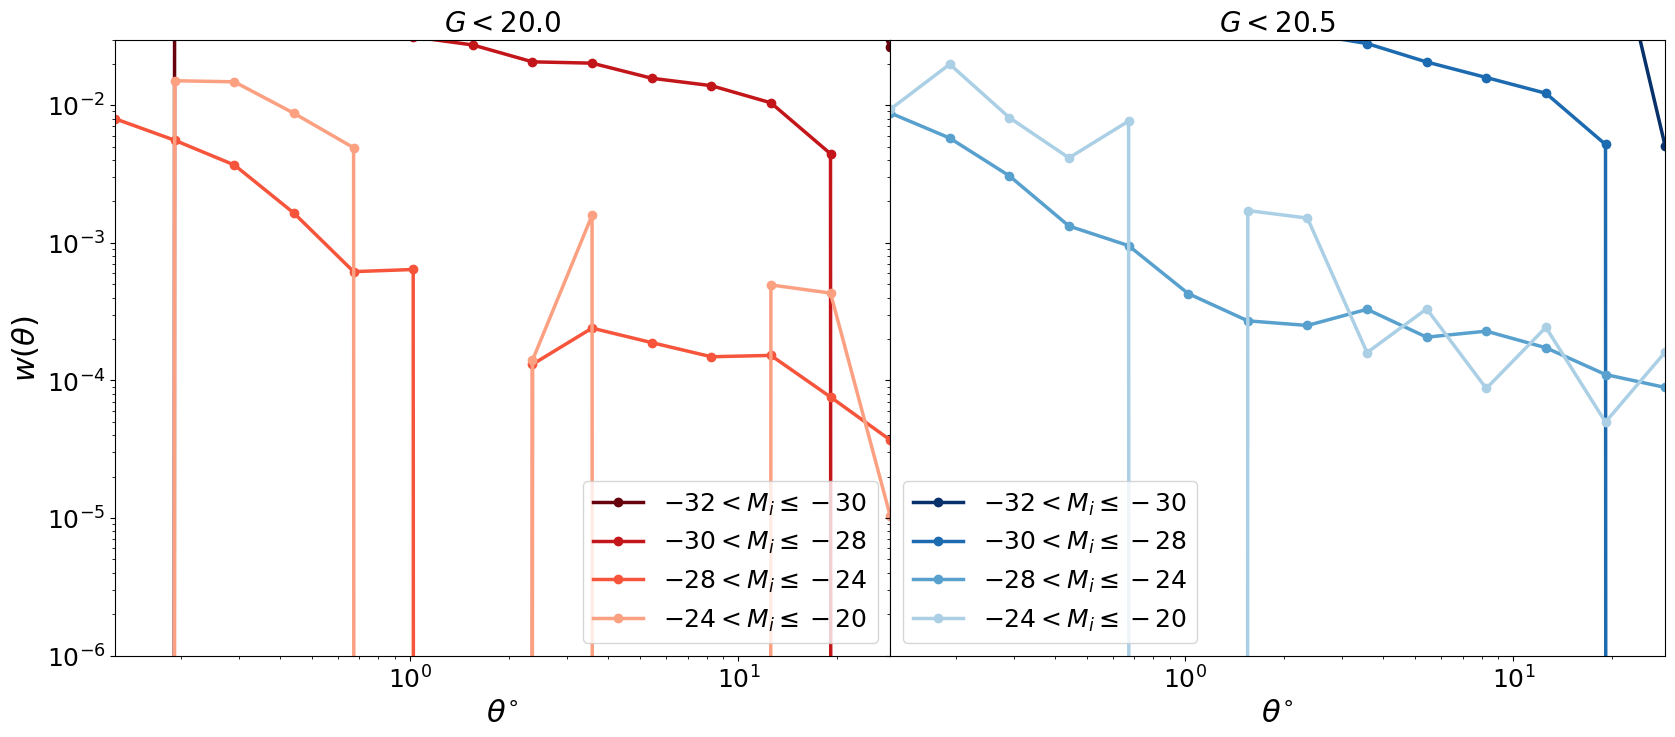

In [45]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])

    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$\theta^{\circ}$')
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 3e-2)
    ax1.legend()
    if i==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()

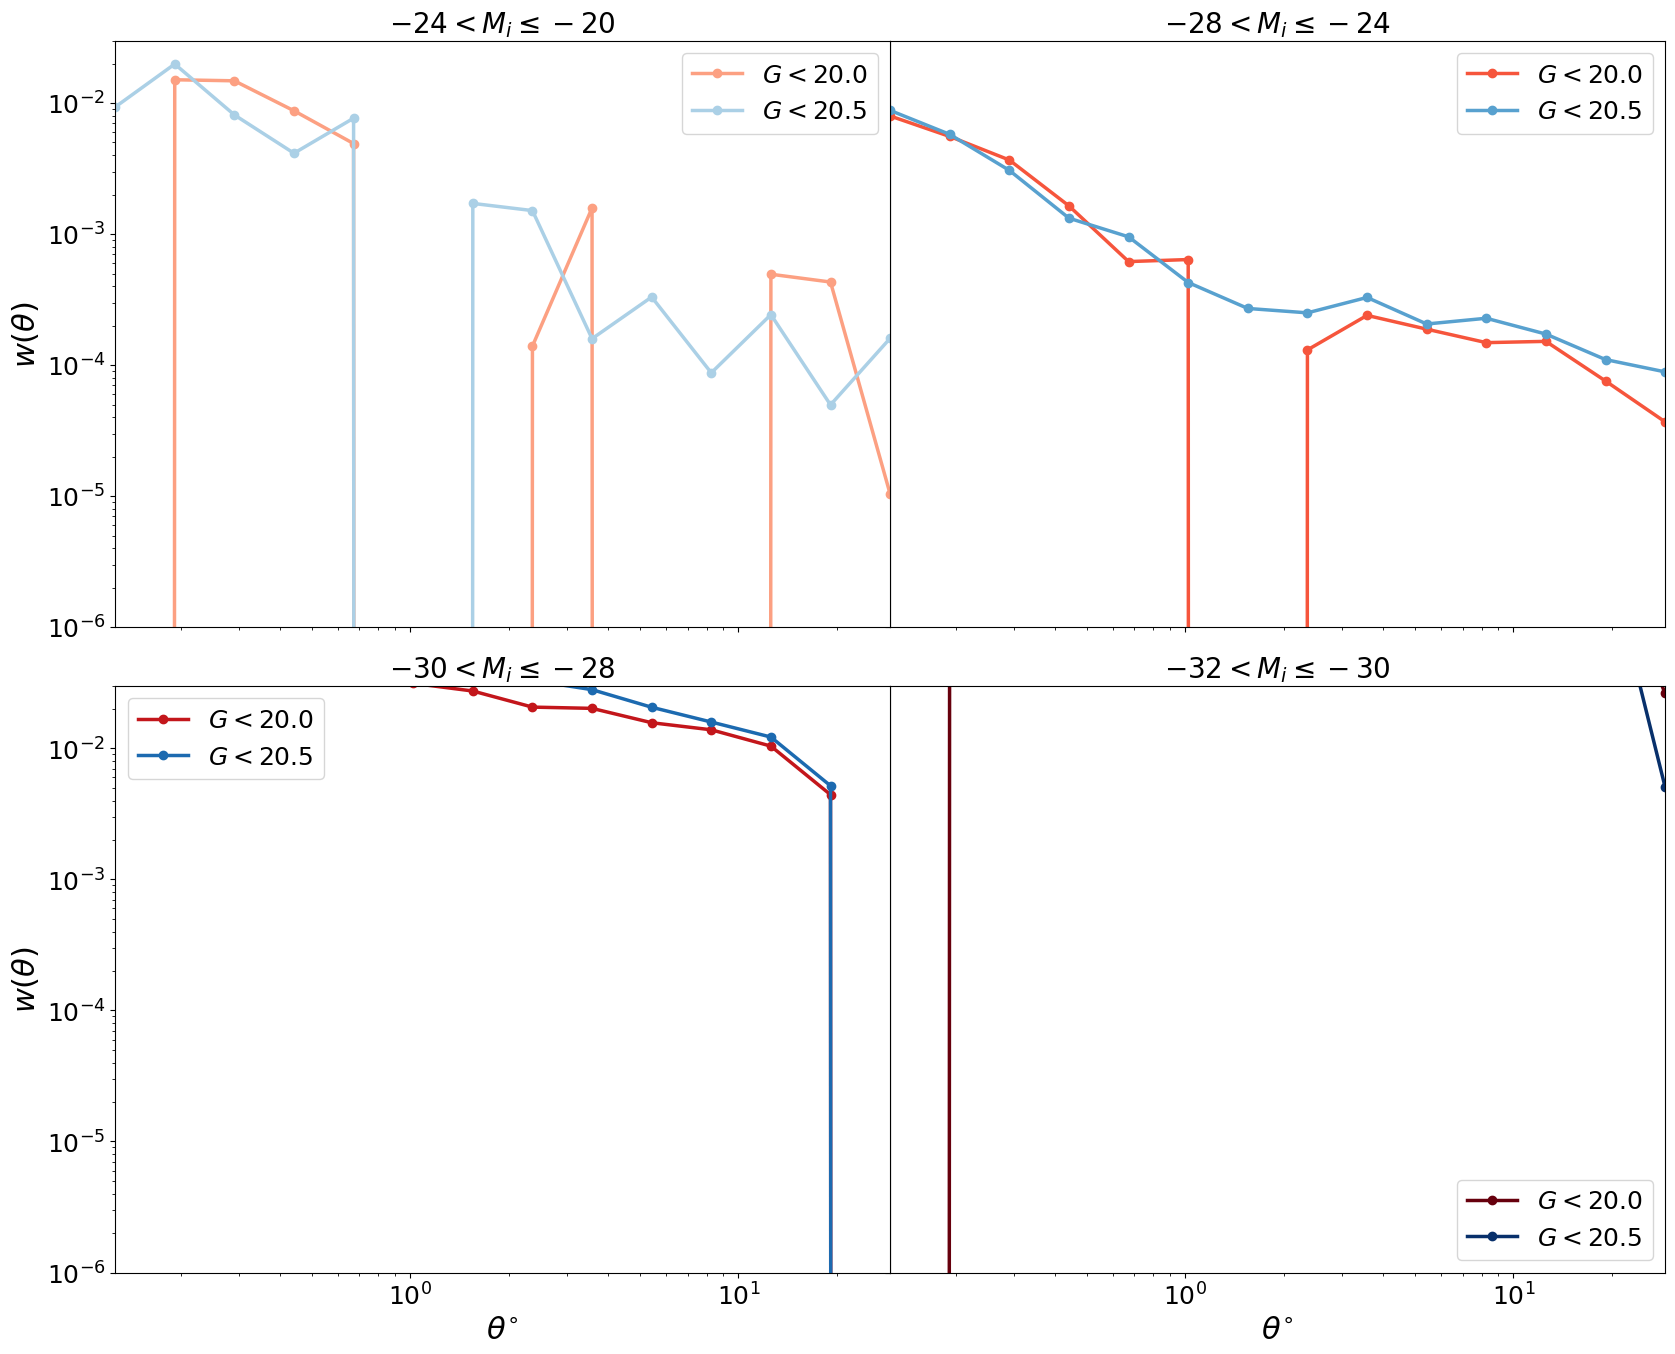

In [46]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title, i in zip(L_array, labels, L_array[::-1]):
    
    ax1 = fig.add_subplot(gs[i])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(thetabins), wtheta[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 3e-2)
    ax1.legend()
    if i%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])
    if i>1:
        ax1.set_xlabel(r'$\theta^{\circ}$')
    else:
        ax1.set_xticklabels([])

plt.show()